In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
#Read in file
df = pd.read_csv(
    "https://raw.githubusercontent.com/GloBIAS-BioimageAnalysts/Survey_2024/main/data/survey2024_headersandcommascleaned_recleaned.csv"
)

In [4]:
#Clean data
df.columns = df.columns.str.strip().str.replace('\n', ' ', regex=True)

In [5]:
df = df.rename(columns={
    'What is your gender': 'Gender'
})


In [6]:
df = df.rename(columns={
    'Are you currently in a permanent position': 'PermanentPosition'
})

In [7]:
gender_ft_counts = (
    df
    .dropna(subset=['Gender', 'PermanentPosition'])
    .groupby(['Gender', 'PermanentPosition'])
    .size()
    .unstack(fill_value=0)
)

gender_ft_counts

PermanentPosition,No,Yes
Gender,,
Female,50,64
Male,59,105
Other,1,0
Prefer not to say,5,4


In [8]:
gender_ft_pct = (
    gender_ft_counts
    .div(gender_ft_counts.sum(axis=1), axis=0) * 100
)

gender_ft_pct.round(1)

PermanentPosition,No,Yes
Gender,,
Female,43.9,56.1
Male,36.0,64.0
Other,100.0,0.0
Prefer not to say,55.6,44.4


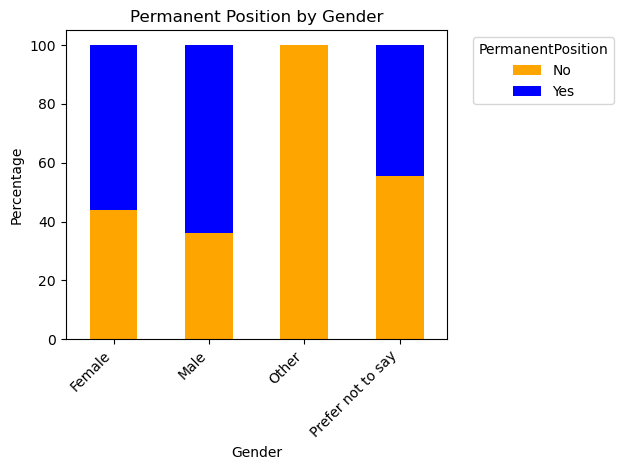

In [9]:
color_map = {
    'Yes': 'blue',
    'No': 'orange'
}

colors = [color_map[col] for col in gender_ft_pct.columns]

gender_ft_pct.plot(
    kind='bar',
    stacked=True,
    color=colors
)

plt.ylabel('Percentage')
plt.title('Permanent Position by Gender')
plt.legend(title='PermanentPosition', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

<Axes: xlabel='Gender'>

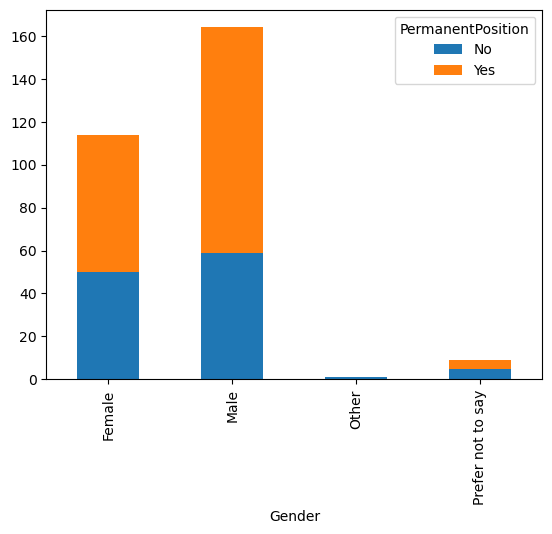

In [10]:
gender_ft_counts.plot(kind='bar', stacked=True)

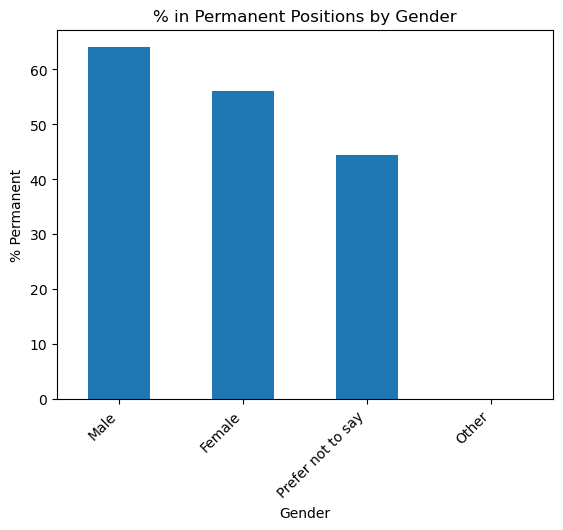

In [12]:
(gender_ft_pct['Yes']
 .sort_values(ascending=False)
 .plot(kind='bar'))

plt.ylabel('% Permanent')
plt.title('% in Permanent Positions by Gender')
plt.xticks(rotation=45, ha='right')
plt.show()